In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot  as plt
import seaborn as sns

In [3]:
btc_day_interval = pd.read_csv("btc_1h_data_2018_to_2025.csv")

btc_day_interval["Direction"] = (
    btc_day_interval["Close"] > btc_day_interval["Open"]
).astype(int)

btc_day_interval["Lag1"] = btc_day_interval["Close"].shift(1)
btc_day_interval["Lag2"] = btc_day_interval["Close"].shift(2)
btc_day_interval["Lag3"] = btc_day_interval["Close"].shift(3)
btc_day_interval["Lag4"] = btc_day_interval["Close"].shift(4)
btc_day_interval["Lag5"] = btc_day_interval["Close"].shift(5)

btc_day_interval_cleaned = btc_day_interval.drop(columns=['Open time', 'Close time']).dropna()
btc_day_interval_cleaned


,Open,High,Low,Close,Volume,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore,Direction,Lag1,Lag2,Lag3,Lag4,Lag5
5,13615.20,13699.00,13526.50,13558.99,404.229046,5.499055e+06,5086,142.331058,1.935710e+06,0,0,13601.01,13410.03,13330.18,13203.06,13529.01
6,13539.00,13800.00,13510.00,13780.41,264.989684,3.613408e+06,4072,126.077500,1.718753e+06,0,1,13558.99,13601.01,13410.03,13330.18,13203.06
7,13780.00,13818.55,13555.02,13570.35,292.188777,4.002026e+06,4340,147.150029,2.016275e+06,0,0,13780.41,13558.99,13601.01,13410.03,13330.18
8,13569.98,13735.24,13400.00,13499.99,271.813553,3.681944e+06,3733,122.809696,1.664737e+06,0,0,13570.35,13780.41,13558.99,13601.01,13410.03
9,13499.97,13670.00,13459.11,13616.99,213.095829,2.893105e+06,3128,96.470199,1.309921e+06,0,1,13499.99,13570.35,13780.41,13558.99,13601.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71394,65703.18,65788.07,65228.33,65314.76,623.008370,4.081045e+07,151605,309.044050,2.025838e+07,0,0,65703.19,65475.21,66095.40,65887.59,66270.55
71395,65314.76,65457.35,65172.60,65392.18,851.955910,5.567046e+07,117356,449.558860,2.938066e+07,0,1,65314.76,65703.19,65475.21,66095.40,65887.59
71396,65392.18,65666.66,65392.18,65594.67,444.864680,2.917019e+07,110666,220.823770,1.447866e+07,0,1,65392.18,65314.76,65703.19,65475.21,66095.40
71397,65594.67,65749.94,65400.00,65527.59,282.656400,1.854426e+07,80506,136.787520,8.975329e+06,0,0,65594.67,65392.18,65314.76,65703.19,65475.21


In [4]:
btc_day_interval.isna().sum()

Open time                       1
Open                            0
High                            0
Low                             0
Close                           0
Volume                          0
Close time                      1
Quote asset volume              0
Number of trades                0
Taker buy base asset volume     0
Taker buy quote asset volume    0
Ignore                          0
Direction                       0
Lag1                            1
Lag2                            2
Lag3                            3
Lag4                            4
Lag5                            5
dtype: int64

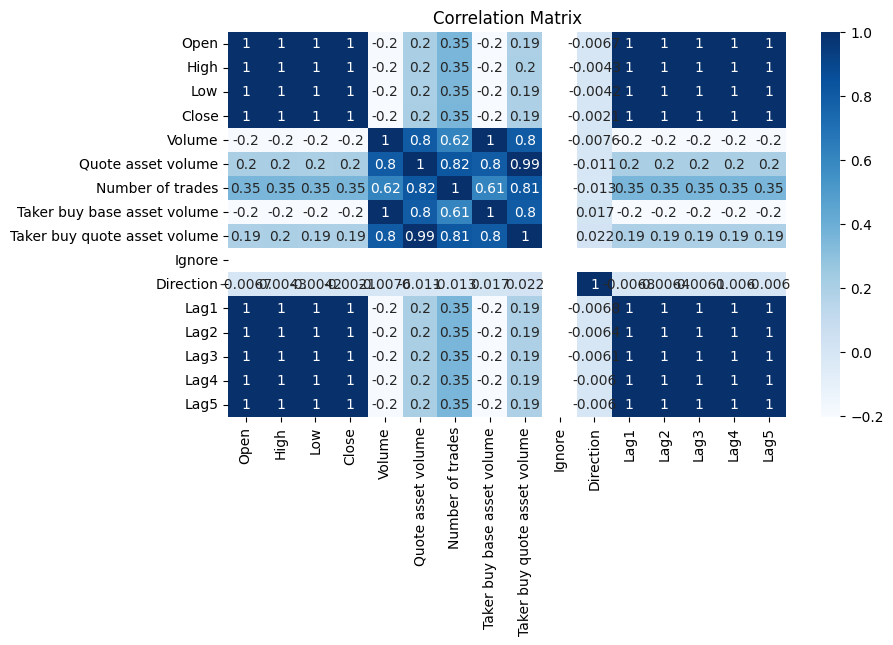

In [5]:
correlation_matrix = btc_day_interval.drop(columns=['Open time', 'Close time']).corr()

plt.figure(figsize=(9, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

In [6]:
tscv = TimeSeriesSplit(n_splits=5)
model = LogisticRegression(max_iter=10000)

X = btc_day_interval_cleaned.drop(columns=["Direction"])
y = btc_day_interval_cleaned["Direction"]

y_true_all = []
y_prob_all = []
scores = []
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=1000))
    ])
    
    pipe.fit(X_train, y_train)
    
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    y_true_all.extend(y_test)
    y_prob_all.extend(y_prob)

# print("CV Accuracy:", sum(scores)/len(scores))

In [7]:
fpr, tpr, thresholds = roc_curve(y_true_all, y_prob_all)
auc_score = roc_auc_score(y_true_all, y_prob_all)

print("AUC:", auc_score)

AUC: 0.8985700374217434


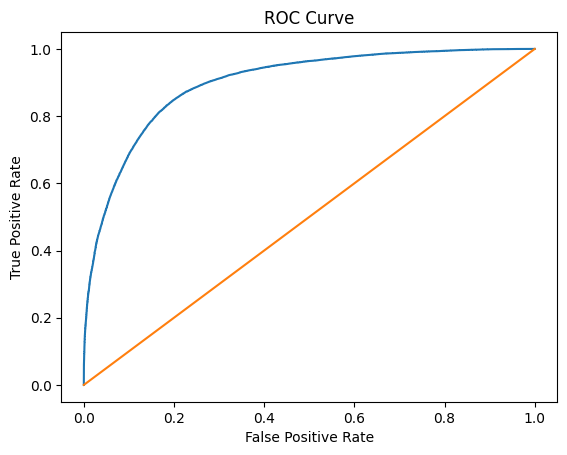

In [8]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [9]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=10000))
])

pipe.fit(X, y)

y_prob_full = pipe.predict_proba(X_test)[:, 1]

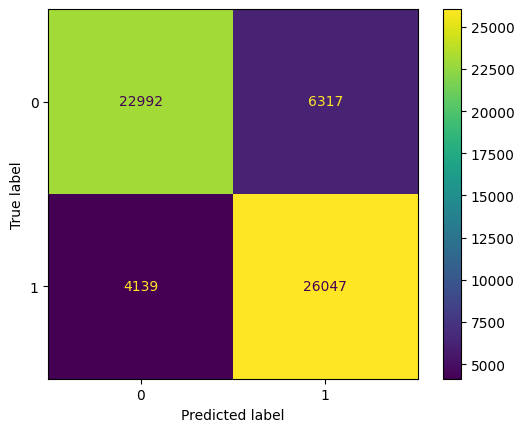

In [10]:
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_all = (np.array(y_prob_all) >= 0.5).astype(int)

cm = confusion_matrix(y_true_all, y_pred_all)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()